<a href="https://colab.research.google.com/github/Sam-Arkle/CS5455/blob/main/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**The assignment:**
for logistic regression: y = 1/(1+exp(-z)), p(t|x) = Bernoulli(y)

For both regression:

    Define distribution of error
    Define the model y = ...
    Derive the cost function, J
    Solve for dJ/dy
    Solve for dy/dz
    Solve for dz/dw
    Solve for the gradient
    Solve for the hessian matrix

Test solution with simulated data

    generated random true w
    generate random x in range (-1, 1)
    compute y from x and true w using the model
    generate random t according to the error distribution p(t|x)
    perform gradient descent starting with a random w with small enough learning rate, alpha
    show that the optimized w is close to the true w
    perform newton-raphson method (gradient and hessian) and show the same.


**Logistic regression**

$y = \frac{1}{1 + e^{-z}}$

$z = ∑_j^Mw_jx_j$

The distribution of error:

$p(t|y) = Bernoulli(y)$

$Bernoulli(x|μ) = μ^x(1-μ)^{1-x}$

We want to maximize this probability for all data points to determine our cost function:

$p(\mathbf{t}|\mathbf{x} = ∏_i p(t^{(i)}|y^{(i)})$

We may underflow to zero, so we take the natural log in order to define our cost function:

$\ln{p(\mathbf{t}|\mathbf{y}} = \ln{\sum_i p(t^{(i)}|y^{(i)})}$

For a given $i$ we know the Bernoulli distribution:

$\ln{(y^t(1-y)^{1-t})}$

$=\ln{y^t} + \ln{(1-y)^{(1-t)}}$

$= t \ln{y} + (1-t) \ln{(1-y)}$

We minimize and arrive at our logloss cost function $J$:

$J = - ∑_i^N (t^i \ln{y}^i + (1-t^i) \ln{(1-y^i)}) $

Solving for $\frac{dJ}{dy}$ we get:

$\frac{dJ}{dy} = ∑^N_i (\frac{t}{y} + \frac{(1-t)}{(1-y)})$


$\frac{dy}{dz} = -1 (1 + e^{-z})^{-2} * \frac{d (1 + e^{-z})}{dz}$

$= -(1+e^{-z})^{-2} * (-e^{-z})$

$= \frac{e^{-z}}{(1 + e^{-z})^2}$

$\frac{dz}{dw_i} = \mathbf{x}_i$

So our gradient is:

$\frac{dJ}{dw_i} = ∑_i^N 2(y^i-t^i)x^i$

and our hessian is:

$\frac{d_2J}{dw_iw_j} = ∑^N_i y^i (1-y^i)*x^i*x^{iT}$


Weights found through gradient descent:  [-0.44853982 -0.19482715]
Actual weights:  [-0.48530722 -0.13566224]


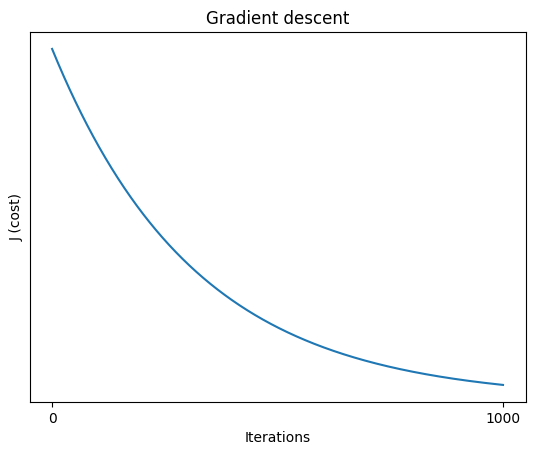

In [61]:
# Now we test our solution with simulated data
import numpy as np
import matplotlib.pyplot as plt

#1. generated random true w -- We want a 'true' weight vector. To keep this simple we can use just two weights
# np.random.seed(3)

M = 2 # The number of features
rt_w = np.random.randn(M)


# 2. generate random x in range (-1, 1)
x = np.random.uniform(-1, 1, (1000,M)) # A random array, 1000 rows and 2 columns, normally distributed

# 3. compute y from x and true w using the model
z = x.dot(rt_w)

y = 1 / (1 + np.exp(-z))

# 4. generate random t according to the error distribution p(t|y) which is a bernoulli distribution
t = np.random.binomial(1,y) # This will give an array of size y with a y probability of success (a 1)

# 5. perform gradient descent starting with a random w with small enough learning rate, alpha
def J(w, X, t):
  z = X.dot(w)
  y = 1 / (1 + np.exp(-z))
  N = len(t)
  J = -np.sum(t * np.log(y) + (1- t) * np.log(1-y)) / N
  return J

def gradient(w, X, t):
  z = X.dot(w)
  y = 1 / (1 + np.exp(-z))
  N = len(t)
  grad = 2*X.T.dot(y-t) / N
  return grad


def hessian(w, X):
  z = X.dot(w)
  y = 1 / (1 + np.exp(-z))
  N = len(t)
  rotated_piece = np.diag(y*(1-y)) # The dimensions were not lining up
  hess = X.T.dot(rotated_piece).dot(X) / len(t)
  return hess

alpha = 0.01
w = np.random.randn(M)
iterations = 1000

j_array = []

for i in range(iterations):
  grad = gradient(w, x, t)
  w -= alpha * grad

  j = J(w, x, t)
  j_array.append(j)


print("Weights found through gradient descent: ", w)
print("Actual weights: ", rt_w)

plt.plot(range(iterations), j_array)
plt.title("Gradient descent")
plt.xlabel("Iterations")
plt.ylabel("J (cost)")
plt.xticks([0, iterations])
plt.yticks([])

plt.show()



Weights found through Newton-Raphson [-0.48163744 -0.07482179]
Actual weights:  [-0.48530722 -0.13566224]


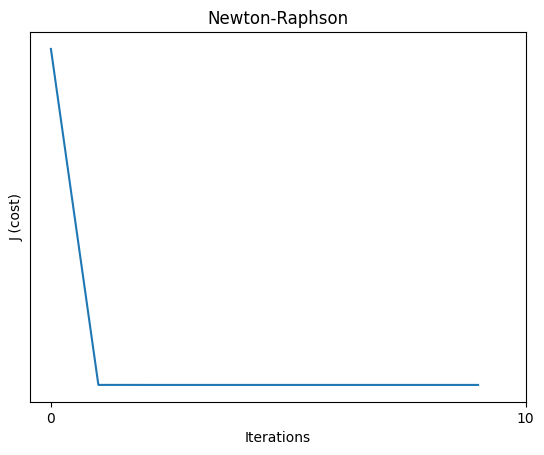

In [66]:
# Going through it again with Newton Raphson

w2 = np.random.randn(M) # Resetting the calculated weights

j_array = []
iterations = 10
for i in range(iterations):
  grad = gradient(w2, x, t)
  hess = hessian(w2, x)
  w2 -= np.linalg.pinv(hess).dot(grad/2)# Using psuedo inverse,

  j = J(w2, x, t)
  j_array.append(j)

print("Weights found through Newton-Raphson", w2)
print("Actual weights: ", rt_w)

plt.plot(range(iterations), j_array)
plt.title("Newton-Raphson")
plt.xlabel("Iterations")
plt.ylabel("J (cost)")
plt.xticks([0, iterations])
plt.yticks([])

plt.show()

# Not happy with this graph, probably a good sign that I am doing something wrong. Need to determine what.